<a href="https://www.kaggle.com/code/lalit7881/global-ai-layoffs-job-market-2020-26-eda?scriptVersionId=315230138" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/belbino/global-ai-layoffs-and-job-market-2020-present/us_labor_indicators.csv
/kaggle/input/datasets/belbino/global-ai-layoffs-and-job-market-2020-present/global_labor_indicators.csv
/kaggle/input/datasets/belbino/global-ai-layoffs-and-job-market-2020-present/README.md
/kaggle/input/datasets/belbino/global-ai-layoffs-and-job-market-2020-present/layoffs_events.csv
/kaggle/input/datasets/belbino/global-ai-layoffs-and-job-market-2020-present/news_sentiment.csv


## Loading dataset

In [2]:

us_labor = pd.read_csv('/kaggle/input/datasets/belbino/global-ai-layoffs-and-job-market-2020-present/us_labor_indicators.csv')
global_labor = pd.read_csv('/kaggle/input/datasets/belbino/global-ai-layoffs-and-job-market-2020-present/global_labor_indicators.csv')
layoffs = pd.read_csv('/kaggle/input/datasets/belbino/global-ai-layoffs-and-job-market-2020-present/layoffs_events.csv')
news = pd.read_csv('/kaggle/input/datasets/belbino/global-ai-layoffs-and-job-market-2020-present/news_sentiment.csv')

In [3]:
print(us_labor.head())
print(global_labor.head())
print(layoffs.head())
print(news.head())

         date  unemployment_rate  jolts_job_openings_k  \
0  2020-01-01                3.6                7124.0   
1  2020-01-04                3.6                7124.0   
2  2020-01-11                3.6                7124.0   
3  2020-01-18                3.6                7124.0   
4  2020-01-25                3.6                7124.0   

   initial_jobless_claims_k  information_sector_emp_k  computer_math_emp_k  \
0                       NaN                    2901.0               4275.0   
1                  224000.0                    2901.0               4275.0   
2                  207000.0                    2901.0               4275.0   
3                  221000.0                    2901.0               4275.0   
4                  210000.0                    2901.0               4275.0   

   financial_emp_k  openings_per_unemployed  tech_emp_yoy_pct  claims_4w_avg  
0           8833.0                 1978.889               NaN            NaN  
1           8833.0      

In [4]:
print(us_labor.info())
print(global_labor.info())
print(layoffs.info())
print(news.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      392 non-null    object 
 1   unemployment_rate         392 non-null    float64
 2   jolts_job_openings_k      392 non-null    float64
 3   initial_jobless_claims_k  391 non-null    float64
 4   information_sector_emp_k  392 non-null    float64
 5   computer_math_emp_k       392 non-null    float64
 6   financial_emp_k           392 non-null    float64
 7   openings_per_unemployed   392 non-null    float64
 8   tech_emp_yoy_pct          380 non-null    float64
 9   claims_4w_avg             388 non-null    float64
dtypes: float64(9), object(1)
memory usage: 30.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------         

In [5]:
print(us_labor.describe())
print(global_labor.describe())

       unemployment_rate  jolts_job_openings_k  initial_jobless_claims_k  \
count         392.000000            392.000000              3.910000e+02   
mean            4.823214           8525.520408              4.471176e+05   
std             2.112585           1853.196387              7.113274e+05   
min             3.400000           4606.000000              1.900000e+05   
25%             3.700000           7089.000000              2.140000e+05   
50%             4.100000           7827.000000              2.250000e+05   
75%             4.500000          10318.000000              3.015000e+05   
max            14.800000          12301.000000              6.137000e+06   

       information_sector_emp_k  computer_math_emp_k  financial_emp_k  \
count                392.000000           392.000000       392.000000   
mean                2900.017857          4888.882653      9021.469388   
std                  126.411771          1409.236310       197.400133   
min                 260

In [6]:
# Check missing values
print(us_labor.isnull().sum())

# Example: fill or drop
us_labor = us_labor.dropna()
# OR
us_labor.fillna(method='ffill', inplace=True)

date                         0
unemployment_rate            0
jolts_job_openings_k         0
initial_jobless_claims_k     1
information_sector_emp_k     0
computer_math_emp_k          0
financial_emp_k              0
openings_per_unemployed      0
tech_emp_yoy_pct            12
claims_4w_avg                4
dtype: int64


In [7]:
print(global_labor.columns)

Index(['year', 'country_code', 'country_name', 'unemployment_rate_pct',
       'youth_unemployment_pct', 'employment_to_pop_pct'],
      dtype='object')


In [8]:
# Clean column names first
global_labor.columns = global_labor.columns.str.strip().str.lower()

print(global_labor.columns)

Index(['year', 'country_code', 'country_name', 'unemployment_rate_pct',
       'youth_unemployment_pct', 'employment_to_pop_pct'],
      dtype='object')


In [9]:
# Clean all column names
for df in [us_labor, global_labor, layoffs, news]:
    df.columns = df.columns.str.strip().str.lower()

# Convert safely (only if exists)
if 'date' in us_labor.columns:
    us_labor['date'] = pd.to_datetime(us_labor['date'])

if 'date' in global_labor.columns:
    global_labor['date'] = pd.to_datetime(global_labor['date'])

if 'date' in layoffs.columns:
    layoffs['date'] = pd.to_datetime(layoffs['date'])

if 'date' in news.columns:
    news['date'] = pd.to_datetime(news['date'])

## EDA

In [10]:
for df in [us_labor, global_labor, layoffs, news]:
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# ===============================
# 4. UNDERSTAND DATA
# ===============================
def basic_info(df, name):
    print(f"\n{name} SHAPE:", df.shape)
    print(df.head())
    print(df.info())
    print(df.describe(include='all'))

basic_info(us_labor, "US LABOR")
basic_info(global_labor, "GLOBAL LABOR")
basic_info(layoffs, "LAYOFFS")
basic_info(news, "NEWS")


US LABOR SHAPE: (380, 10)
         date  unemployment_rate  jolts_job_openings_k  \
12 2020-03-14                4.4                5894.0   
13 2020-03-21                4.4                5894.0   
14 2020-03-28                4.4                5894.0   
15 2020-04-01               14.8                4606.0   
16 2020-04-04               14.8                4606.0   

    initial_jobless_claims_k  information_sector_emp_k  computer_math_emp_k  \
12                  273000.0                    2902.0               5763.0   
13                 2914000.0                    2902.0               5763.0   
14                 5946000.0                    2902.0               5763.0   
15                 5946000.0                    2643.0              10880.0   
16                 6137000.0                    2643.0              10880.0   

    financial_emp_k  openings_per_unemployed  tech_emp_yoy_pct  claims_4w_avg  
12           8855.0                 1339.545              0.03       

In [11]:
for df in [us_labor, global_labor, layoffs, news]:
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# ===============================
# 4. UNDERSTAND DATA
# ===============================
def basic_info(df, name):
    print(f"\n{name} SHAPE:", df.shape)
    print(df.head())
    print(df.info())
    print(df.describe(include='all'))

basic_info(us_labor, "US LABOR")
basic_info(global_labor, "GLOBAL LABOR")
basic_info(layoffs, "LAYOFFS")
basic_info(news, "NEWS")


US LABOR SHAPE: (380, 10)
         date  unemployment_rate  jolts_job_openings_k  \
12 2020-03-14                4.4                5894.0   
13 2020-03-21                4.4                5894.0   
14 2020-03-28                4.4                5894.0   
15 2020-04-01               14.8                4606.0   
16 2020-04-04               14.8                4606.0   

    initial_jobless_claims_k  information_sector_emp_k  computer_math_emp_k  \
12                  273000.0                    2902.0               5763.0   
13                 2914000.0                    2902.0               5763.0   
14                 5946000.0                    2902.0               5763.0   
15                 5946000.0                    2643.0              10880.0   
16                 6137000.0                    2643.0              10880.0   

    financial_emp_k  openings_per_unemployed  tech_emp_yoy_pct  claims_4w_avg  
12           8855.0                 1339.545              0.03       

In [12]:
def convert_date(df):
    for col in df.columns:
        if 'date' in col:
            df[col] = pd.to_datetime(df[col], errors='coerce')

convert_date(us_labor)
convert_date(global_labor)
convert_date(layoffs)
convert_date(news)

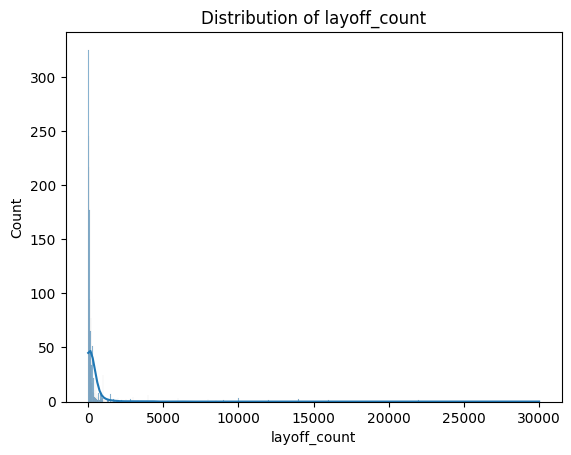

In [13]:
num_cols = layoffs.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.histplot(layoffs[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


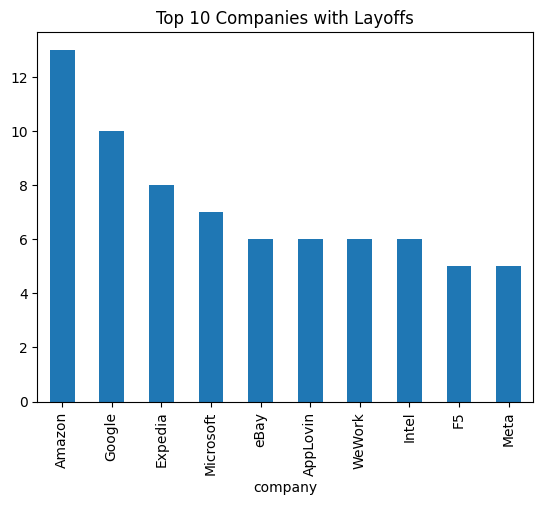

In [14]:
if 'company' in layoffs.columns:
    top_companies = layoffs['company'].value_counts().head(10)
    plt.figure()
    top_companies.plot(kind='bar')
    plt.title("Top 10 Companies with Layoffs")
    plt.show()

In [15]:
date_col = None
for col in layoffs.columns:
    if 'date' in col:
        date_col = col
        break

if date_col and 'laid_off' in layoffs.columns:
    trend = layoffs.groupby(date_col)['laid_off'].sum()
    
    plt.figure(figsize=(10,5))
    trend.plot()
    plt.title("Layoffs Trend Over Time")
    plt.show()


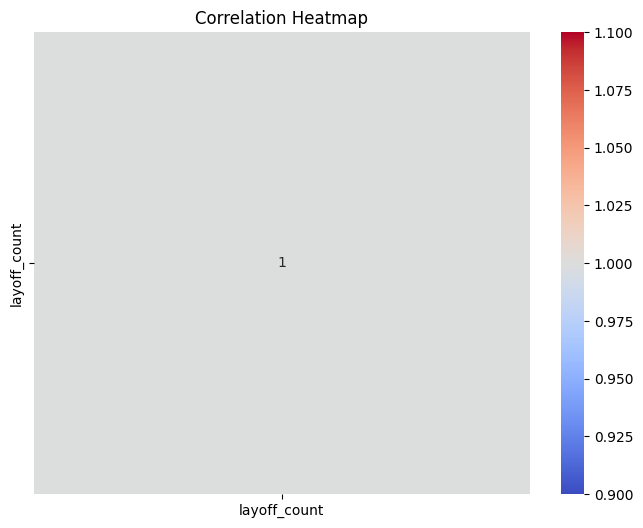

In [16]:
corr = layoffs.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
if 'industry' in layoffs.columns and 'laid_off' in layoffs.columns:
    industry_layoffs = layoffs.groupby('industry')['laid_off'].sum().sort_values(ascending=False).head(10)
    
    plt.figure()
    industry_layoffs.plot(kind='bar')
    plt.title("Layoffs by Industry")
    plt.show()

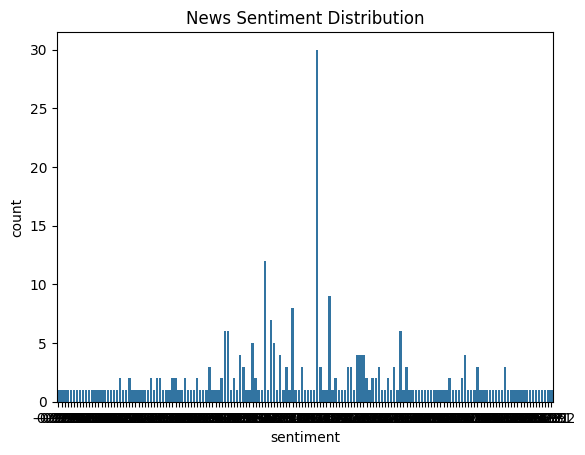

In [18]:
if 'sentiment' in news.columns:
    plt.figure()
    sns.countplot(x=news['sentiment'])
    plt.title("News Sentiment Distribution")
    plt.show()

In [19]:
common_date = None

for col in layoffs.columns:
    if 'date' in col:
        common_date = col
        break

if common_date and common_date in news.columns:
    merged = pd.merge(layoffs, news, on=common_date, how='inner')
    
    print("\nMerged Dataset Shape:", merged.shape)
    
    if 'laid_off' in merged.columns and 'sentiment_score' in merged.columns:
        sns.scatterplot(x=merged['sentiment_score'], y=merged['laid_off'])
        plt.title("Sentiment vs Layoffs")
        plt.show()


Merged Dataset Shape: (304, 20)


## Feature enigneering

In [20]:
print(layoffs.columns)

Index(['company', 'location', 'layoff_count', 'date', 'pct_workforce',
       'industry', 'source_url', 'stage', 'raised_mm', 'country',
       'is_ai_company'],
      dtype='object')


In [21]:

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor



layoffs.columns = layoffs.columns.str.strip().str.lower().str.replace(" ", "_")

# ===============================
# TARGET
# ===============================
target = 'layoff_count'
layoffs = layoffs.dropna(subset=[target])

# ===============================
# REMOVE OUTLIERS (CRITICAL)
# ===============================
q_low = layoffs[target].quantile(0.01)
q_high = layoffs[target].quantile(0.99)

layoffs = layoffs[(layoffs[target] >= q_low) & (layoffs[target] <= q_high)]

# ===============================
# FEATURE ENGINEERING
# ===============================
layoffs['date'] = pd.to_datetime(layoffs['date'], errors='coerce')
layoffs['year'] = layoffs['date'].dt.year
layoffs['month'] = layoffs['date'].dt.month

# Clean categorical
cat_cols = ['industry', 'country', 'stage']
for col in cat_cols:
    layoffs[col] = layoffs[col].fillna('unknown').astype(str)

# Clean numeric
num_cols = ['pct_workforce', 'raised_mm', 'is_ai_company']
for col in num_cols:
    layoffs[col] = pd.to_numeric(layoffs[col], errors='coerce').fillna(0)

# ===============================
# FEATURES
# ===============================
features = cat_cols + ['year', 'month'] + num_cols
features = [col for col in features if col in layoffs.columns]

X = layoffs[features]
y = np.log1p(layoffs[target])

# ===============================
# BASELINE MODEL (IMPORTANT)
# ===============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

baseline_pred = np.full_like(y_test, y_train.mean())
print("Baseline MAE:", mean_absolute_error(np.expm1(y_test), np.expm1(baseline_pred)))

# ===============================
# PIPELINE
# ===============================
categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(include=np.number).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

# ===============================
# TRAIN
# ===============================
model.fit(X_train, y_train)

# ===============================
# PREDICT
# ===============================
y_pred = model.predict(X_test)

y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

# ===============================
# EVALUATION
# ===============================
print("\n✅ Improved Model Performance")
print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))
print("R2:", r2_score(y_test_actual, y_pred_actual))

Baseline MAE: 151.00511514227935

✅ Improved Model Performance
MAE: 141.21158019117655
R2: 0.054909838871585515


## Thank you...pls upvote!!!!!!!!
